In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import shap
import matplotlib.pyplot as plt
import joblib
# !pip install shap

In [8]:
df = pd.read_csv('customer_attrition_db_customer_summary.csv')

df.head()

,company_id,churn_flag,plan_tier,billing_cycle,industry,acquisition_channel,mrr,total_tickets,serious_tickets,avg_satisfaction_score,total_events,total_active_users,lifespan_days,champion_reliance_percentage,late_window_events,early_window_events
0,COMP-0001,Y,starter,annual,Non-Profit,referral,462.26,10,5,2.6250,24,3,102,41.67,7,17
1,COMP-0002,N,starter,annual,Legal,partner,152.27,2,1,1.5000,1027,7,544,16.94,120,218
2,COMP-0003,N,starter,annual,Finance,referral,432.49,7,2,2.7143,982,5,546,21.28,105,217
3,COMP-0004,N,professional,annual,Consulting,paid,964.64,2,0,4.0000,1272,13,427,8.81,194,360
4,COMP-0005,N,starter,monthly,Consulting,referral,395.64,2,2,4.0000,966,3,546,34.06,100,214


In [9]:
df.describe()

df.info()

df['churn_flag'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   company_id                    350 non-null    object 
 1   churn_flag                    350 non-null    object 
 2   plan_tier                     350 non-null    object 
 3   billing_cycle                 350 non-null    object 
 4   industry                      350 non-null    object 
 5   acquisition_channel           350 non-null    object 
 6   mrr                           350 non-null    float64
 7   total_tickets                 350 non-null    int64  
 8   serious_tickets               350 non-null    int64  
 9   avg_satisfaction_score        343 non-null    float64
 10  total_events                  350 non-null    int64  
 11  total_active_users            350 non-null    int64  
 12  lifespan_days                 350 non-null    int64  
 13  champ

churn_flag
N    299
Y     51
Name: count, dtype: int64

In [10]:
df['total_events'].min()
df[df['total_events'] == 0]

,company_id,churn_flag,plan_tier,billing_cycle,industry,acquisition_channel,mrr,total_tickets,serious_tickets,avg_satisfaction_score,total_events,total_active_users,lifespan_days,champion_reliance_percentage,late_window_events,early_window_events


Confirmed: total_events minimum is 1. No company has zero usage events. Clean data, not a SQL artifact.

In [11]:
csat_median = df['avg_satisfaction_score'].median()
csat_median

df['avg_satisfaction_score'] = df['avg_satisfaction_score'].fillna(csat_median)
df.info()
#Filled the 7 missing satisfaction scores with the median (3.5) rather than the mean.
#More robust to outliers on a 1–5 scale, and produces a plausible real value.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   company_id                    350 non-null    object 
 1   churn_flag                    350 non-null    object 
 2   plan_tier                     350 non-null    object 
 3   billing_cycle                 350 non-null    object 
 4   industry                      350 non-null    object 
 5   acquisition_channel           350 non-null    object 
 6   mrr                           350 non-null    float64
 7   total_tickets                 350 non-null    int64  
 8   serious_tickets               350 non-null    int64  
 9   avg_satisfaction_score        350 non-null    float64
 10  total_events                  350 non-null    int64  
 11  total_active_users            350 non-null    int64  
 12  lifespan_days                 350 non-null    int64  
 13  champ

In [12]:
df['churn_flag'] = df['churn_flag'].map({'Y' : 1, 'N' : 0})
df['churn_flag'].value_counts()

churn_flag
0    299
1     51
Name: count, dtype: int64

In [13]:
x = df.drop(columns=['company_id', 'churn_flag', 'lifespan_days', 'total_events', 'late_window_events', 'early_window_events'])
y = df['churn_flag']

## Feature Selection & Leakage Prevention:
Prior to modeling, time-bound metrics (lifespan_days, total_events, late_window_events, early_window_events) were explicitly dropped. As discovered during EDA, lifespan_days is right-censored, and dropping activity is a symptom of a churned account, not a predictive cause. Keeping them would cause severe Data Leakage. The model is built strictly on firmographics, financial exposure, and support friction to create a true early-warning system.

In [14]:
x = pd.get_dummies(x, drop_first = True)
x.head()

,mrr,total_tickets,serious_tickets,avg_satisfaction_score,total_active_users,champion_reliance_percentage,plan_tier_professional,plan_tier_starter,billing_cycle_monthly,industry_Education,...,industry_Manufacturing,industry_Media,industry_Non-Profit,industry_Real Estate,industry_Retail,industry_Technology,acquisition_channel_organic,acquisition_channel_paid,acquisition_channel_partner,acquisition_channel_referral
0,462.26,10,5,2.6250,3,41.67,False,True,False,False,...,False,False,True,False,False,False,False,False,False,True
1,152.27,2,1,1.5000,7,16.94,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
2,432.49,7,2,2.7143,5,21.28,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
3,964.64,2,0,4.0000,13,8.81,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,395.64,2,2,4.0000,3,34.06,False,True,True,False,...,False,False,False,False,False,False,False,False,False,True


In [15]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)
(x_train.shape, x_test.shape, y_test.value_counts())

((280, 27),
 (70, 27),
 churn_flag
 0    60
 1    10
 Name: count, dtype: int64)

In [18]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)
print("--Classification Report--")
print(classification_report(y_test, rf_pred))

importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': x.columns, 'Importance': importances})
print("\n--TOP 10 DRIVERS--")
print(feature_importance_df.sort_values(by='Importance', ascending=False).head(10).to_string(index=False))

--Classification Report--
              precision    recall  f1-score   support

           0       0.94      0.98      0.96        60
           1       0.86      0.60      0.71        10

    accuracy                           0.93        70
   macro avg       0.90      0.79      0.83        70
weighted avg       0.93      0.93      0.92        70


--TOP 10 DRIVERS--
                     Feature  Importance
      avg_satisfaction_score    0.271215
             serious_tickets    0.231557
               total_tickets    0.118669
champion_reliance_percentage    0.101566
                         mrr    0.083671
          total_active_users    0.049152
      plan_tier_professional    0.011313
       billing_cycle_monthly    0.010945
             industry_Retail    0.010630
    acquisition_channel_paid    0.010412


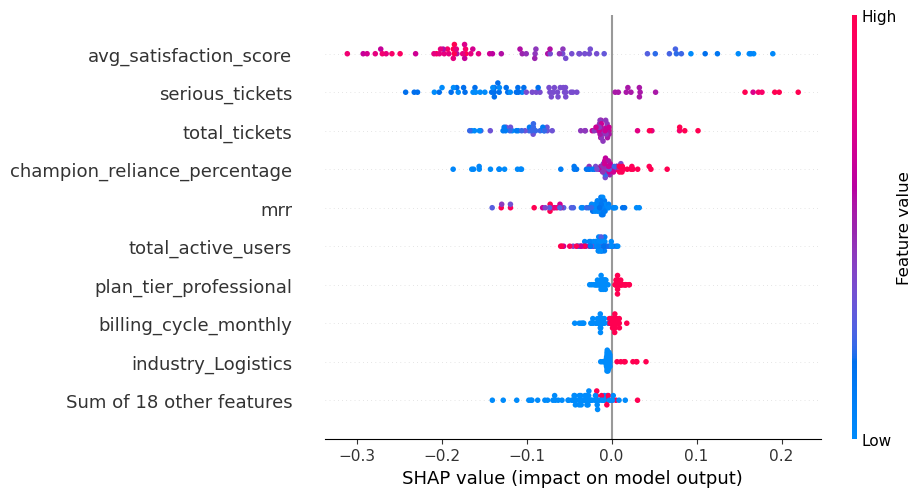

In [19]:
plt.close('all')

explainer = shap.TreeExplainer(rf_model)


shap_obj = explainer(x_test)

shap_churn = shap_obj[:, :, 1]

shap_churn.feature_names = x_train.columns.tolist()

shap.plots.beeswarm(shap_churn, max_display=10)

## Executive SHAP Summary:
The beeswarm plot successfully validates the SQL Exploratory Data Analysis.

Support Friction: avg_satisfaction_score and serious_tickets are the dominant predictors. Blue dots (low satisfaction) and red dots (high serious tickets) push strongly to the right (Churn).

Champion Reliance: Accounts where a single user drives the majority of activity are mathematically proven to be high flight risks if that champion leaves.

In [20]:
joblib.dump(rf_model, 'churn_rf_model.pkl')

joblib.dump(list(x_train.columns), 'model_columns.pkl')

print('Model and Columns saved.')

Model and Columns saved.
